# Air Pollution (AQI) Forecasting for Hebbal, Bengaluru — LSTM

**Pipeline:** `hebbal_clean.csv` (built by `01_clean_data.py`) → EDA → sliding windows (48 h lookback → 24 h forecast) → LSTM vs naive baselines → evaluation on held-out 2024.

**Chronological split (no shuffling — this is a time series):**
- Train: Jul 2018 – Dec 2022
- Validation: 2023
- Test: 2024 (never touched during training)

In [1]:
# One-time setup: installs everything into this notebook's kernel environment.
# Re-running is harmless (pip skips already-installed packages).
%pip install pandas numpy matplotlib tensorflow

# After the FIRST install: Kernel -> Restart Kernel, then run from the next cell onward.

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.1-cp312


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers

LOOKBACK, HORIZON = 48, 24
np.random.seed(42)
keras.utils.set_random_seed(42)
print('keras', keras.__version__)

keras 3.15.0


## 1. Load cleaned data and engineer features

Cyclical time features use sin/cos pairs so hour 23 and hour 0 are close, and wind direction (degrees) is likewise encoded as a unit vector.

In [3]:
df = pd.read_csv('../data/hebbal_clean.csv', parse_dates=['datetime'], index_col='datetime')

df['wd_sin'] = np.sin(np.deg2rad(df.wind_dir)); df['wd_cos'] = np.cos(np.deg2rad(df.wind_dir))
df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24); df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)
df['doy_sin'] = np.sin(2*np.pi*df.index.dayofyear/365); df['doy_cos'] = np.cos(2*np.pi*df.index.dayofyear/365)
df['dow'] = df.index.dayofweek / 6.0

FEATURES = ['AQI', 'temp', 'rh', 'wind_speed', 'precip', 'pressure',
            'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'dow']
print(df.shape); df.head(3)

(57014, 14)


,AQI,temp,rh,wind_speed,wind_dir,precip,pressure,wd_sin,wd_cos,hour_sin,hour_cos,doy_sin,doy_cos,dow
datetime,,,,,,,,,,,,,,
2018-07-01 10:00:00,42.00,25.3,69,9.9,251,0.0,913.2,-0.945519,-0.325568,5.000000e-01,-0.866025,0.008607,-0.999963,1.0
2018-07-01 11:00:00,42.04,26.2,64,11.5,250,0.1,913.0,-0.939693,-0.342020,2.588190e-01,-0.965926,0.008607,-0.999963,1.0
2018-07-01 12:00:00,42.08,26.5,62,10.1,253,0.2,912.4,-0.956305,-0.292372,1.224647e-16,-1.000000,0.008607,-0.999963,1.0


## 2. Exploratory data analysis

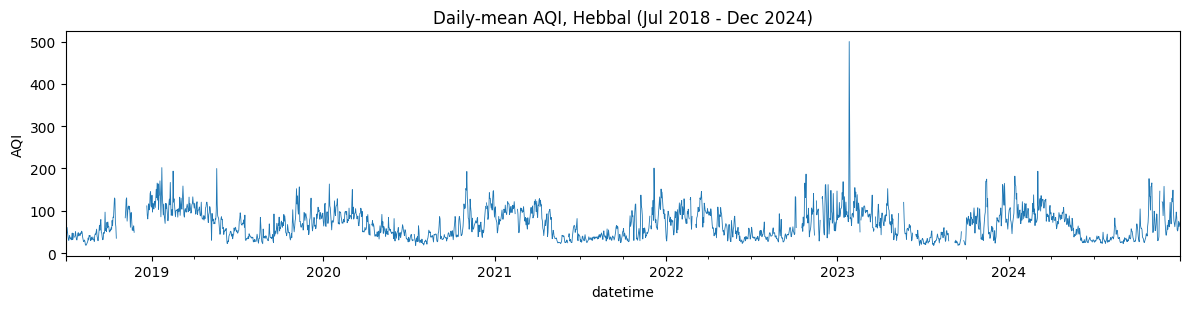

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.2))
df.AQI.resample('D').mean().plot(ax=ax, lw=0.6)
ax.set_title('Daily-mean AQI, Hebbal (Jul 2018 - Dec 2024)'); ax.set_ylabel('AQI')
plt.tight_layout(); plt.savefig('../figures/fig1_series.png', dpi=150); plt.show()

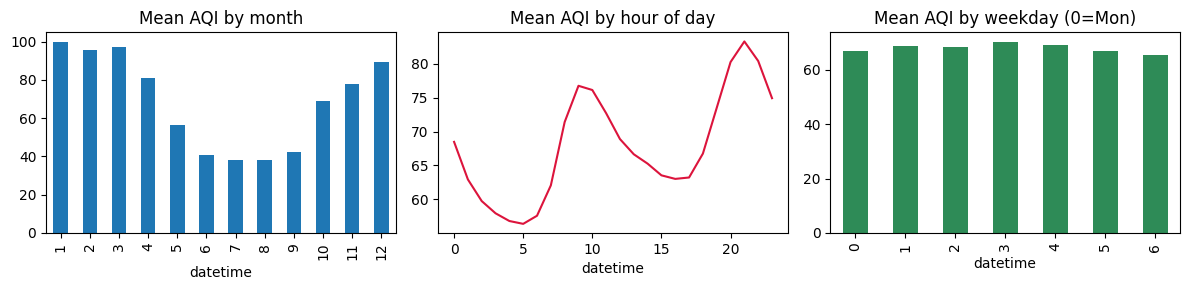

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
df.groupby(df.index.month).AQI.mean().plot(kind='bar', ax=axes[0], title='Mean AQI by month')
df.groupby(df.index.hour).AQI.mean().plot(ax=axes[1], color='crimson', title='Mean AQI by hour of day')
df.groupby(df.index.dayofweek).AQI.mean().plot(kind='bar', ax=axes[2], color='seagreen', title='Mean AQI by weekday (0=Mon)')
plt.tight_layout(); plt.savefig('../figures/fig2_seasonality.png', dpi=150); plt.show()

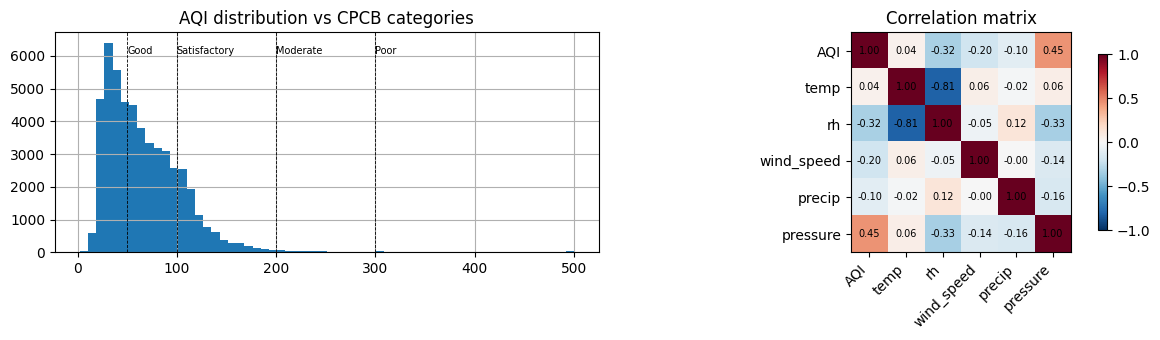

Autocorrelation of AQI: {1: np.float64(0.895), 6: np.float64(0.572), 12: np.float64(0.568), 24: np.float64(0.618), 48: np.float64(0.496), 168: np.float64(0.376)}
AQI
Good            0.416
Satisfactory    0.401
Moderate        0.172
Poor            0.007
V.Poor+         0.004
Name: proportion, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df.AQI.hist(bins=60, ax=axes[0])
for x, lab in [(50, 'Good'), (100, 'Satisfactory'), (200, 'Moderate'), (300, 'Poor')]:
    axes[0].axvline(x, color='k', lw=0.6, ls='--')
    axes[0].text(x, axes[0].get_ylim()[1]*0.9, lab, fontsize=7)
axes[0].set_title('AQI distribution vs CPCB categories')
corr = df[['AQI', 'temp', 'rh', 'wind_speed', 'precip', 'pressure']].corr()
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr))); axes[1].set_xticklabels(corr.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(corr))); axes[1].set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
axes[1].set_title('Correlation matrix'); fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.savefig('../figures/fig3_dist_corr.png', dpi=150); plt.show()

print('Autocorrelation of AQI:', {l: round(df.AQI.dropna().autocorr(l), 3) for l in [1, 6, 12, 24, 48, 168]})
print(pd.cut(df.AQI.dropna(), [0, 50, 100, 200, 300, 500],
      labels=['Good', 'Satisfactory', 'Moderate', 'Poor', 'V.Poor+']).value_counts(normalize=True).round(3))

## 3. Sliding windows

Input: last 48 h of all 13 features. Target: next 24 h of AQI (multi-step vector output).
Windows touching a missing value are **dropped**, never imputed. Scaling statistics come from the training period only (no leakage).

In [7]:
X_raw = df[FEATURES].to_numpy(np.float32)
y_raw = df['AQI'].to_numpy(np.float32)
n = len(df)
ok = ~np.isnan(X_raw).any(axis=1)
yok = ~np.isnan(y_raw)

idx = np.array([t for t in range(LOOKBACK, n - HORIZON)
                if ok[t-LOOKBACK:t].all() and yok[t:t+HORIZON].all()])
print('valid windows:', len(idx))

times = df.index
train_m = times[idx] <= '2022-12-31 23:00'
val_m = (times[idx] > '2022-12-31 23:00') & (times[idx] <= '2023-12-31 23:00')
test_m = times[idx] > '2023-12-31 23:00'

# scale on training period only
tr_span = X_raw[: idx[train_m].max()]
mu = np.nanmean(tr_span, axis=0); sd = np.nanstd(tr_span, axis=0); sd[sd == 0] = 1
y_mu = np.nanmean(y_raw[: idx[train_m].max()]); y_sd = np.nanstd(y_raw[: idx[train_m].max()])

Xn = (X_raw - mu) / sd
X = np.stack([Xn[t-LOOKBACK:t] for t in idx]).astype(np.float32)
Y = np.stack([y_raw[t:t+HORIZON] for t in idx]).astype(np.float32)
Yn = (Y - y_mu) / y_sd

Xtr, Ytr = X[train_m], Yn[train_m]
Xva, Yva = X[val_m], Yn[val_m]
Xte, Yte_raw = X[test_m], Y[test_m]
print('train/val/test:', Xtr.shape, Xva.shape, Xte.shape)

valid windows: 37648
train/val/test: (26353, 48, 13) (4096, 48, 13) (7199, 48, 13)


## 4. Naive baselines

Any NN must beat these to be worth anything:
**Persistence** — every future hour equals the last observed AQI. **Seasonal naive** — AQI(t+h) equals AQI at the same hour yesterday.

In [8]:
last_obs = Xte[:, -1, 0] * sd[0] + mu[0]
persist = np.repeat(last_obs[:, None], HORIZON, axis=1)
seas = Xte[:, -24:, 0] * sd[0] + mu[0]

def report(name, p, true):
    rmse = np.sqrt(np.mean((p - true) ** 2)); mae = np.mean(np.abs(p - true))
    hs = {h: np.sqrt(np.mean((p[:, h] - true[:, h]) ** 2)) for h in [0, 5, 11, 23]}
    print(f'{name:14s} RMSE {rmse:6.2f}  MAE {mae:6.2f} | RMSE@1h {hs[0]:.1f}  @6h {hs[5]:.1f}  @12h {hs[11]:.1f}  @24h {hs[23]:.1f}')
    return {'rmse': float(rmse), 'mae': float(mae), 'rmse_by_h': {str(k+1): float(v) for k, v in hs.items()}}

res = {}
res['Persistence'] = report('Persistence', persist, Yte_raw)
res['SeasonalNaive'] = report('SeasonalNaive', seas, Yte_raw)

Persistence    RMSE  36.43  MAE  21.14 | RMSE@1h 17.4  @6h 37.3  @12h 38.7  @24h 33.1
SeasonalNaive  RMSE  32.64  MAE  19.11 | RMSE@1h 31.9  @6h 32.7  @12h 32.5  @24h 33.1


## 5. LSTM model

Stacked LSTM (64 → 32) with dropout 0.2, dense head, 24 linear outputs (one per forecast hour). Loss: MSE on standardized AQI. Early stopping on validation loss restores the best weights.

In [9]:
model = keras.Sequential([
    layers.Input((LOOKBACK, len(FEATURES))),
    layers.LSTM(64, return_sequences=True, dropout=0.2),
    layers.LSTM(32, dropout=0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(HORIZON),
])
model.compile(keras.optimizers.Adam(5e-4), 'mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,056 (140.84 KB)

 Trainable params: 36,056 (140.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
52/52 - 10s - 186ms/step - loss: 0.8296 - mae: 0.6634 - val_loss: 1.6426 - val_mae: 0.6395
Epoch 2/60
52/52 - 7s - 136ms/step - loss: 0.5808 - mae: 0.5053 - val_loss: 1.5682 - val_mae: 0.6175
Epoch 3/60
52/52 - 9s - 171ms/step - loss: 0.5558 - mae: 0.4847 - val_loss: 1.5580 - val_mae: 0.6161
Epoch 4/60
52/52 - 7s - 137ms/step - loss: 0.5478 - mae: 0.4794 - val_loss: 1.5623 - val_mae: 0.6197
Epoch 5/60
52/52 - 6s - 121ms/step - loss: 0.5390 - mae: 0.4737 - val_loss: 1.5639 - val_mae: 0.6277
Epoch 6/60
52/52 - 6s - 113ms/step - loss: 0.5301 - mae: 0.4682 - val_loss: 1.5693 - val_mae: 0.6212
Epoch 7/60
52/52 - 6s - 110ms/step - loss: 0.5189 - mae: 0.4618 - val_loss: 1.5644 - val_mae: 0.6245
Epoch 8/60
52/52 - 6s - 110ms/step - loss: 0.5136 - mae: 0.4580 - val_loss: 1.5651 - val_mae: 0.6194
Epoch 9/60
52/52 - 6s - 110ms/step - loss: 0.5034 - mae: 0.4512 - val_loss: 1.5552 - val_mae: 0.6155
Epoch 10/60
52/52 - 7s - 126ms/step - loss: 0.4932 - mae: 0.4463 - val_loss: 1.5326 - val_

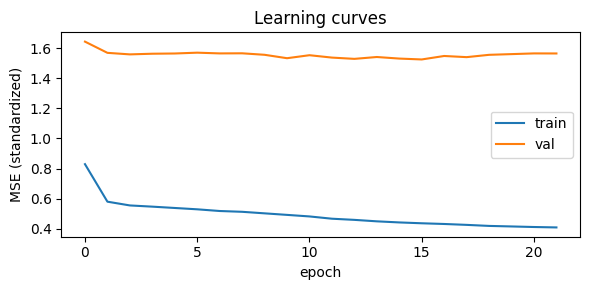

In [10]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
hist = model.fit(Xtr, Ytr, validation_data=(Xva, Yva),
                 epochs=60, batch_size=512, callbacks=[es], verbose=2)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(hist.history['loss'], label='train'); ax.plot(hist.history['val_loss'], label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE (standardized)'); ax.legend(); ax.set_title('Learning curves')
plt.tight_layout(); plt.savefig('../figures/fig4_learning.png', dpi=150); plt.show()

## 6. Evaluation on 2024 test year

LSTM           RMSE  29.26  MAE  18.08 | RMSE@1h 24.4  @6h 28.9  @12h 29.8  @24h 30.7


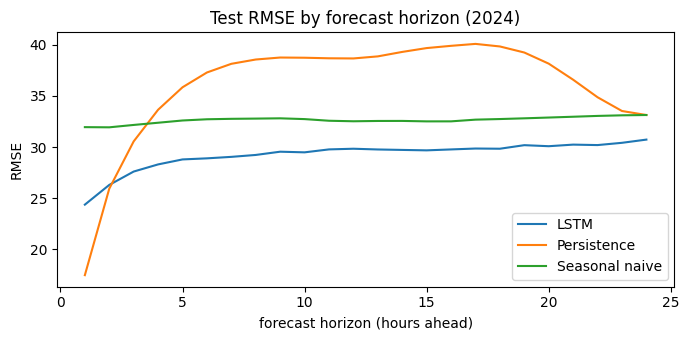

In [11]:
pred = model.predict(Xte, batch_size=1024, verbose=0) * y_sd + y_mu
res['LSTM'] = report('LSTM', pred, Yte_raw)
json.dump(res, open('../model/metrics.json', 'w'), indent=1)

hs = range(1, HORIZON + 1)
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, p in [('LSTM', pred), ('Persistence', persist), ('Seasonal naive', seas)]:
    ax.plot(hs, [np.sqrt(np.mean((p[:, h-1] - Yte_raw[:, h-1])**2)) for h in hs], label=name)
ax.set_xlabel('forecast horizon (hours ahead)'); ax.set_ylabel('RMSE'); ax.legend()
ax.set_title('Test RMSE by forecast horizon (2024)')
plt.tight_layout(); plt.savefig('../figures/fig5_horizon_rmse.png', dpi=150); plt.show()

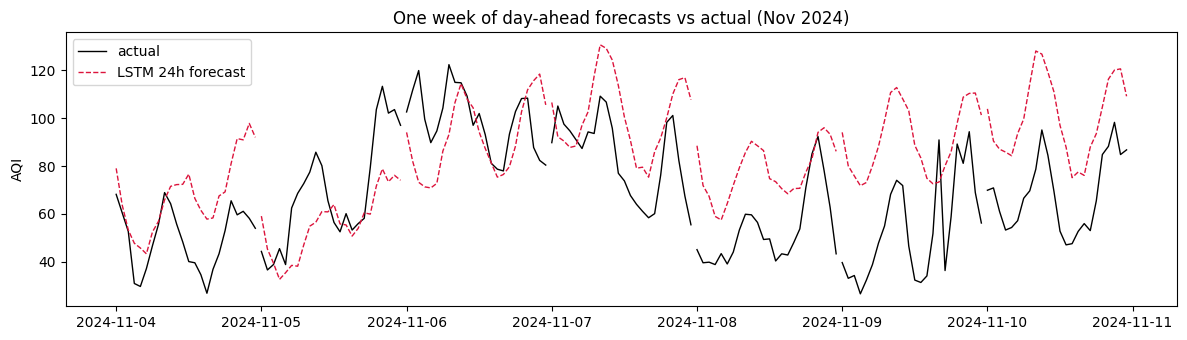

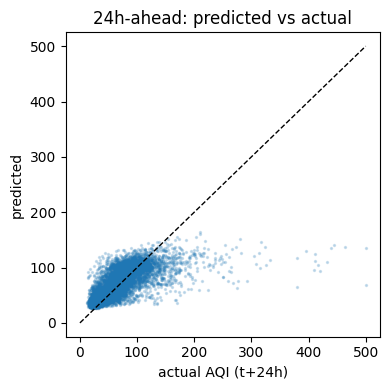

saved: lstm_aqi.keras, metrics.json, fig1-7


In [12]:
# sample week: chained 24h-ahead predictions vs actual
te_times = times[idx[test_m]]
start = np.searchsorted(te_times, pd.Timestamp('2024-11-04'))
sel = range(start, start + 7 * 24, 24)
fig, ax = plt.subplots(figsize=(12, 3.5))
for k, s in enumerate(sel):
    t = pd.date_range(te_times[s], periods=HORIZON, freq='h')
    ax.plot(t, Yte_raw[s], color='k', lw=1, label='actual' if k == 0 else None)
    ax.plot(t, pred[s], color='crimson', lw=1, ls='--', label='LSTM 24h forecast' if k == 0 else None)
ax.legend(); ax.set_title('One week of day-ahead forecasts vs actual (Nov 2024)'); ax.set_ylabel('AQI')
plt.tight_layout(); plt.savefig('../figures/fig6_sample_week.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(Yte_raw[:, 23], pred[:, 23], s=2, alpha=0.2)
lims = [0, max(Yte_raw[:, 23].max(), pred[:, 23].max())]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('actual AQI (t+24h)'); ax.set_ylabel('predicted'); ax.set_title('24h-ahead: predicted vs actual')
plt.tight_layout(); plt.savefig('../figures/fig7_scatter.png', dpi=150); plt.show()

model.save('../model/lstm_aqi.keras')
print('saved: ../model/lstm_aqi.keras, ../model/metrics.json, ../figures/fig1-7')

## 7. Conclusions (fill in after running)

- Compare the LSTM row of the metrics table against both baselines, overall and at 12–24 h horizons.
- Expected pattern: persistence wins at 1–3 h (AQI is highly autocorrelated); the LSTM should pull ahead as the horizon grows.
- Note the CPCB category implications: an RMSE of ~15–25 AQI points is small relative to category widths (50–100 points).
- Limitations: single station; ERA5 reanalysis weather rather than on-site sensors; 2024 AQI computed from concentrations (documented in `01_clean_data.py`); no future weather forecasts used as inputs.